## Settings

In [39]:
## auto reload modules
%reload_ext autoreload
%autoreload 2

## Dependencies

In [40]:
## libraries
import sys
import logging
from pathlib import Path

## path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

## modules
from src.estimators.factories import load_estimators
from src.data.builders import (
    load_processed_data,
    load_perturbed_data
)
from src.evaluators.perturbing import (
    train_perturbed_transfer,
    train_perturbed_recovery,
    train_perturbed_consensus,
    compile_perturbed_transfer,
    compile_perturbed_recovery,
    compile_perturbed_consensus,
    find_perturbed_max,
    spec_marginal_delta,
    stat_perturbed_tost
)
from src.visualizers.visualizing import plot_consensus

## constants
from src.evaluators.metrics import CONSENSUS_METRICS
from src.evaluators.config import (
    FEAT_X,
    FEAT_Z,
    TARGET
)

## Initialization

In [41]:
## reproducibility
N_REPEATS = 30
RANDOM_STATE = 42

## load data and models
_disable = logging.root.manager.disable
logging.disable(logging.INFO)
try:
    data_proc = load_processed_data()
    data_pert_all = load_perturbed_data()
    data_pert = {
        key: data_pert_all[key]
        for key in [
            "network_perturbed", 
            "invariants_perturbed", 
            "process_perturbed", 
            "signatures_perturbed"
        ]
        if key in data_pert_all
    }
finally:
    logging.disable(_disable)
    models = load_estimators(random_state = RANDOM_STATE)

## view data shape
n_obs, n_feat = data_proc.shape
print(f"Original Data: {n_feat} features, {n_obs} observations")
print("Perturbed Data:")
for json_key, methods in data_pert.items():
    print(f"  {json_key}:")
    for method, intense in methods.items():
        pert_df = next(iter(intense.values()))
        n_r, n_c = pert_df.shape
        print(f"   - {method}: {n_c} features, {n_r} observations")

## view model surface
n_mods = len(models)
print(f"Learned Models: {n_mods} estimators")

Original Data: 32 features, 25 observations
Perturbed Data:
  network_perturbed:
   - node_sample: 24 features, 24 observations
   - rewire: 24 features, 24 observations
   - sparsify: 24 features, 24 observations
  invariants_perturbed:
   - jitter: 24 features, 24 observations
   - noise: 24 features, 24 observations
   - subset: 24 features, 24 observations
  process_perturbed:
   - bootstrapping: 10 features, 24 observations
   - scaling: 10 features, 24 observations
   - smoothing: 10 features, 24 observations
  signatures_perturbed:
   - jitter: 10 features, 24 observations
   - noise: 10 features, 24 observations
   - subset: 10 features, 24 observations
Learned Models: 9 estimators


## Training

In [42]:
## perturbation transfer training
if "results_dict_perturbed_transfer" not in globals():
    results_dict_perturbed_transfer = train_perturbed_transfer(
        data = data_proc,
        models = models,
        data_pert = data_pert,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
    )

In [43]:
## perturbation recovery training
if "results_dict_perturbed_recovery" not in globals():
    results_dict_perturbed_recovery = train_perturbed_recovery(
        data = data_proc,
        models = models,
        data_pert = data_pert,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE,
    )

In [44]:
## perturbation pairwise consensus training
if "results_dict_perturbed_consensus" not in globals():
    results_dict_perturbed_consensus = train_perturbed_consensus(
        data = data_proc,
        models = models,
        data_pert = data_pert,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE,
    )

## Post-Processing

In [45]:
## compile perturbation domain transfer results
results_perturbed_transfer, recovery_perturbed_transfer = compile_perturbed_transfer(
    results = results_dict_perturbed_transfer
)

## compile perturbation structural recovery results
results_perturbed_recovery = compile_perturbed_recovery(
    results = results_dict_perturbed_recovery
)

## compile perturbation pairwise consensus results
results_perturbed_consensus = compile_perturbed_consensus(
    results = results_dict_perturbed_consensus
)

## Domain Transfer Equivalence Test
The domain transfer test probes whether perturbations preserve EI transfer performance. Predictions are generated under the same frozen LOGO-CV (domain) protocol and scored by EI per (model x domain). Each perturbation method is tested for statistical equivalence against the original baseline EI using two one-sided tests (TOST) with paired Wilcoxon signed-rank statistics.

- **$H_0$**: The absolute difference meets or exceeds the margin ($|\Delta| \ge \delta$).
- **$H_1$**: The absolute difference falls strictly within the margin ($|\Delta| < \delta$).

Rejecting $H_0$ establishes that the perturbation effect is negligibly small relative to $\delta$.

### Maximum-Intensity Protocol
Only the highest intensity setting per perturbation method enters the test. Baseline and perturbed EI values are paired on (model $\times$ domain), matching the structural recovery test. This yields one paired comparison per model $\times$ domain $\times$ method and prevents a dense intensity sweep from inflating sample size.

### Empirical Test Specification
The equivalence margin $\delta$ is derived from baseline variability across learners on the original EI transfer results. Half the interquartile range of the baseline EI values sets $\delta$, anchoring the margin to natural performance dispersion rather than to perturbation effects.

In [46]:
## maximum intensity per perturbation method
results_perturbed_transfer_max = find_perturbed_max(
    results = results_perturbed_transfer
)

## empirical delta specification
delta_transfer = spec_marginal_delta(
    results = results_perturbed_transfer,
    feat_value = ["ei"],
    track = "frozen",
    method = "iqr",
    scale = 1.0,  ## iqr range
    decimals = 3
)

## tost equivalence test across all perturbation methods
results_transfer = stat_perturbed_tost(
    results = results_perturbed_transfer_max,
    feat_value = ["ei"],
    feat_group = ["perturbation", "method"],
    track = "frozen",
    delta = delta_transfer,
    decimals = 3
)

display(results_transfer)

Paired TOST (Wilcoxon Signed-Rank): n = 45, δ = 0.085
H₀: |Δ EI| ≥ δ
H₁: |Δ EI| < δ
Median Δ EI: Median of paired differences, not the difference of marginal medians
Rank-biserial r: Paired effect size, equivalence determined by TOST
TOST p: max(Upper p, Lower p)
Holm-adj. p: Holm-Bonferroni adjusted TOST p-value
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


Median Δ EI Rank-biserial r TOST p Holm-adj. p  \
Perturbation Method                                                         
network      node sample         0.000          -0.411  0.000       0.000   
             rewire              0.000          -0.521  0.000       0.000   
             sparsify            0.000          -0.401  0.000       0.000   
invariants   jitter              0.000          -0.523  0.000       0.000   
             noise               0.000          -0.368  0.000       0.000   
             subset              0.000          -0.749  0.000       0.000   
process      bootstrapping      -0.000          -0.057  0.000       0.000   
             scaling             0.026           0.621  0.005       0.005   
             smoothing           0.004          -0.013  0.000       0.000   
signatures   jitter              0.005           0.237  0.000       0.000   
             noise               0.003           0.281  0.000       0.000   
             subset              0.000          -0.872  0.000       0.000   

                           Sig.  Eq.  
Perturbation Method                   
network      node sample    ***  Yes  
             rewire         ***  Yes  
             sparsify       ***  Yes  
invariants   jitter         ***  Yes  
             noise          ***  Yes  
             subset         ***  Yes  
process      bootstrapping  ***  Yes  
             scaling         **  Yes  
             smoothing      ***  Yes  
signatures   jitter         ***  Yes  
             noise          ***  Yes  
             subset         ***  Yes

_All four perturbation methods satisfy TOST equivalence at maximum intensity. Median EI shifts are uniformly small, with the largest change (0.006, process) below one-quarter of the prespecified margin. These results indicate that domain-transfer performance is stable across substantial perturbations to network structure, graph invariant representations, stochastic process structure, and process signature representations, supporting robustness within the tested equivalence design._

## Structural Recovery Equivalence Test
The structural recovery test probes whether predictions preserve the observed capacity ordering.Predictions are generated under the same frozen LOGO-CV (domain) protocol then scored by the composite consensus index CI = f(rho, rbo, dcr) per (model x domain). Each perturbation method is tested for statistical equivalence against the original baseline CI using two one-sided tests (TOST) with paired Wilcoxon signed-rank statistics.

- **$H_0$**: The absolute difference meets or exceeds the margin ($|\Delta| \ge \delta$).
- **$H_1$**: The absolute difference falls strictly within the margin ($|\Delta| < \delta$).

Rejecting $H_0$ establishes that the perturbation effect is negligibly small relative to $\delta$.

### Maximum-Intensity Protocol
Only the highest intensity setting per perturbation method enters the test. Baseline and perturbed CI values are paired on (model $\times$ domain), matching the transfer EI test. This yields one paired comparison per model $\times$ domain $\times$ method and prevents a dense intensity sweep from inflating sample size.

### Empirical Test Specification
The equivalence margin $\delta$ is derived from baseline variability across learners on the original structural recovery CI results. Half the interquartile range of the baseline CI values sets $\delta$, anchoring the margin to natural performance dispersion rather than to perturbation effects.

In [47]:
## structural recovery equivalence at maximum perturbation intensity
results_perturbed_recovery_max = find_perturbed_max(
    results = results_perturbed_recovery
)

## empirical delta specification
delta_recovery = spec_marginal_delta(
    results = results_perturbed_recovery,
    feat_value = ["ci"],
    track = "frozen",
    method = "iqr",
    scale = 1.0,  ## iqr range
    decimals = 2
)

## tost equivalence test across all perturbation methods
results_recovery = stat_perturbed_tost(
    results = results_perturbed_recovery_max,
    feat_value = ["ci"],
    feat_group = ["perturbation", "method"],
    track = "frozen",
    delta = delta_recovery,
    decimals = 3
)

display(results_recovery)

Paired TOST (Wilcoxon Signed-Rank): n = 45, δ = 0.27
H₀: |Δ CI| ≥ δ
H₁: |Δ CI| < δ
Median Δ CI: Median of paired differences, not the difference of marginal medians
Rank-biserial r: Paired effect size, equivalence determined by TOST
TOST p: max(Upper p, Lower p)
Holm-adj. p: Holm-Bonferroni adjusted TOST p-value
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


Median Δ CI Rank-biserial r TOST p Holm-adj. p  \
Perturbation Method                                                         
network      node sample         0.000          -0.594  0.000       0.000   
             rewire              0.000          -0.673  0.000       0.000   
             sparsify            0.000          -0.662  0.000       0.000   
invariants   jitter              0.000          -0.639  0.000       0.000   
             noise               0.000          -0.631  0.000       0.000   
             subset              0.000          -0.865  0.000       0.000   
process      bootstrapping      -0.007          -0.268  0.000       0.000   
             scaling            -0.031          -0.235  0.000       0.000   
             smoothing           0.007           0.144  0.000       0.000   
signatures   jitter              0.008           0.144  0.000       0.000   
             noise               0.020           0.364  0.000       0.000   
             subset              0.000          -0.930  0.000       0.000   

                           Sig.  Eq.  
Perturbation Method                   
network      node sample    ***  Yes  
             rewire         ***  Yes  
             sparsify       ***  Yes  
invariants   jitter         ***  Yes  
             noise          ***  Yes  
             subset         ***  Yes  
process      bootstrapping  ***  Yes  
             scaling        ***  Yes  
             smoothing      ***  Yes  
signatures   jitter         ***  Yes  
             noise          ***  Yes  
             subset         ***  Yes

## Model Consensus Evaluation
The model consensus evaluation probes whether maximum-intensity perturbations preserve agreement among independently trained frontiers. Unlike the domain-transfer and structural-recovery sections, this is a descriptive stability analysis rather than a formal equivalence test. Agreement is computed across all model pairs using the same consensus metrics.

- **Spearman (`ρ`)**: Global rank agreement between paired model frontiers.
- **Rank-Biased Overlap (`RBO`)**: Top-weighted agreement, emphasizing the high-capacity tail.
- **Distance Correlation (`DCR`)**: Nonlinear dependence between paired model frontiers.
- **Composite Index (`CI`)**: Geometric mean of agreement-scaled `ρ`, `RBO`, and `DCR`.

### Maximum-Intensity Protocol
Only the highest intensity setting per perturbation method enters the evaluation. The unperturbed baseline is retained for comparison, and perturbed values are summarized across model pairs within each method.

### Reporting Convention
Each perturbation method contributes one value per model pair at maximum intensity. The preview reports medians across all retained pairwise comparisons. Prior to compounding, `ρ` is rescaled from `[-1, 1]` to `[0, 1]` so that negative rank agreement lowers `CI` without collapsing to a single floor. Higher values indicate stronger perturbation-stable model consensus.

In [51]:
## preview results
results_perturbed_consensus_max = find_perturbed_max(
    results = results_perturbed_consensus
)
results_perturbed_consensus_max[CONSENSUS_METRICS].median()

rho    0.921739
rbo    0.817543
dcr    0.857657
ci     0.851136
dtype: float64

## Visualization

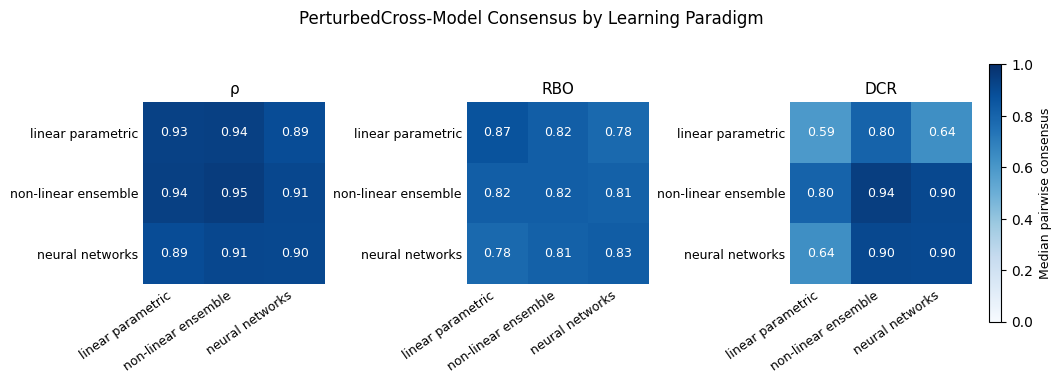

In [ ]:
## paradigm-level consensus heatmaps
results_perturbed_consensus_plot = results_perturbed_consensus_max.loc[
    results_perturbed_consensus_max["perturbation"] != "baseline"
].copy()

fig, ax, mat = plot_consensus(
    results = results_perturbed_consensus_plot,
    title = "PerturbedCross-Model Consensus by Learning Paradigms"
)